<a href="https://colab.research.google.com/github/dophanthanhdat/final/blob/main/boitayyyy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Tạo thư mục dữ liệu giả lập (Thay bằng dataset thật của bạn sau này)
classes = ['sinh_dao', 'tri_dao', 'tam_dao']
base_dir = 'palm_dataset'
os.makedirs(base_dir, exist_ok=True)

for cls in classes:
    os.makedirs(os.path.join(base_dir, cls), exist_ok=True)
    # Tạo 10 ảnh random cho mỗi lớp để code không bị lỗi khi train
    for i in range(10):
        img = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        tf.keras.utils.save_img(os.path.join(base_dir, cls, f'img_{i}.jpg'), img)

print("-> Đã khởi tạo dữ liệu giả lập thành công!")

# 2. Chuẩn bị Data Loader
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_gen = datagen.flow_from_directory(
    base_dir, target_size=(224, 224), batch_size=4, class_mode='categorical', subset='training'
)
val_gen = datagen.flow_from_directory(
    base_dir, target_size=(224, 224), batch_size=4, class_mode='categorical', subset='validation'
)

# 3. Khởi tạo mô hình (Transfer Learning với MobileNetV2 cho nhẹ)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(len(classes), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Đóng băng các layer của base_model
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical-split', metrics=['accuracy'])

# 4. Train mô hình (Chạy 3 epochs làm mẫu)
print("-> Bắt đầu huấn luyện mô hình...")
model.fit(train_gen, validation_data=val_gen, epochs=3)
print("-> Train xong! Mô hình đã sẵn sàng nhận diện.")

# Định nghĩa các câu dự đoán vận mệnh tương ứng với các lớp
fortune_telling = {
    0: "Đường Sinh Đạo: Vận mệnh tràn đầy năng lượng, sức khỏe dồi dào, gặp nhiều may mắn trong cuộc sống!",
    1: "Đường Trí Đạo: Tư duy logic cực tốt, có khả năng thăng tiến xa trên con đường học vấn và sự nghiệp công nghệ.",
    2: "Đường Tâm Đạo: Tình cảm phong phú, sắp tới có quý nhân phù trợ, nhân duyên hanh thông!"
}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from google.colab import drive
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Mount Drive
drive.mount('/content/drive')

# Đường dẫn gốc (Bạn kiểm tra lại tên thư mục trên Drive của mình nhé)
BASE_PATH = '/content/drive/MyDrive/palmistry'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Đường dẫn gốc (Bạn kiểm tra lại tên thư mục trên Drive của mình nhé)
BASE_PATH = '/content/drive/MyDrive/palmistry'

def train_palm_model(line_name, epochs=15):
    print(f"\n--- ĐANG HUẤN LUYỆN MÔ HÌNH CHO: {line_name.upper()} ---")
    data_path = os.path.join(BASE_PATH, line_name)

    # 1. Tiền xử lý ảnh và Augmentation (Tăng cường dữ liệu)
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        validation_split=0.2 # Chia 20% làm tập test
    )

    train_gen = datagen.flow_from_directory(
        data_path, target_size=(224, 224), batch_size=16,
        class_mode='categorical', subset='training'
    )

    val_gen = datagen.flow_from_directory(
        data_path, target_size=(224, 224), batch_size=16,
        class_mode='categorical', subset='validation'
    )

    # Lưu lại danh sách các class (Ví dụ: dai_cung, mo_nhat...)
    class_indices = train_gen.class_indices
    labels = {v: k for k, v in class_indices.items()}

    # 2. Xây dựng mô hình dùng MobileNetV2 (nhẹ, phù hợp làm App)
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation='relu')(x)
    predictions = Dense(len(class_indices), activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Đóng băng các lớp đầu để train nhanh hơn
    for layer in base_model.layers:
        layer.trainable = False

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # 3. Chạy Training
    model.fit(train_gen, validation_data=val_gen, epochs=epochs)

    return model, labels

# --- CHẠY TRAIN CHO 3 MÔ HÌNH ---
# Lưu ý: Nếu dữ liệu ít, bạn có thể giảm epochs xuống
model_sinh, labels_sinh = train_palm_model('sinh_dao', epochs=20)
model_tri, labels_tri = train_palm_model('tri_dao', epochs=20)
model_tam, labels_tam = train_palm_model('tam_dao', epochs=20)

print("\n=> Đã hoàn thành huấn luyện 3 mô hình!")


--- ĐANG HUẤN LUYỆN MÔ HÌNH CHO: SINH_DAO ---
Found 1676 images belonging to 4 classes.
Found 417 images belonging to 4 classes.
Epoch 1/20
 10/105 ━━━━━━━━━━━━━━━━━━━━ 27s 285ms/step - accuracy: 0.3303 - loss: 1.5731

KeyboardInterrupt: 

Saving 011987.jpg to 011987.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


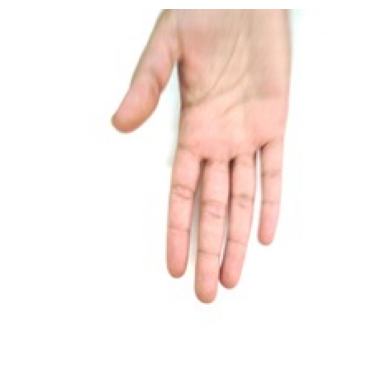

🔮 --- KẾT QUẢ PHÂN TÍCH CHỈ TAY --- 🔮
🔹 Đường Sinh Đạo: TRUNG BINH
🔹 Đường Trí Đạo: DOC LOM
🔹 Đường Tam Đạo: VONG GIUA
----------------------------------------


In [13]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_destiny():
    uploaded = files.upload()

    for fn in uploaded.keys():
        path = fn
        img = image.load_img(path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Dự đoán từ 3 mô hình
        res_sinh = labels_sinh[np.argmax(model_sinh.predict(img_array))]
        res_tri = labels_tri[np.argmax(model_tri.predict(img_array))]
        res_tam = labels_tam[np.argmax(model_tam.predict(img_array))]

        # Hiển thị ảnh
        plt.imshow(img)
        plt.axis('off')
        plt.show()

        print("🔮 --- KẾT QUẢ PHÂN TÍCH CHỈ TAY --- 🔮")
        print(f"🔹 Đường Sinh Đạo: {res_sinh.replace('_', ' ').upper()}")
        print(f"🔹 Đường Trí Đạo: {res_tri.replace('_', ' ').upper()}")
        print(f"🔹 Đường Tam Đạo: {res_tam.replace('_', ' ').upper()}")
        print("-" * 40)

# Chạy hàm này để kiểm tra ảnh
predict_destiny()

👉 Hãy chọn một bức ảnh chụp lòng bàn tay rõ nét từ máy tính của bạn...


Saving 019035.jpg to 019035 (1).jpg


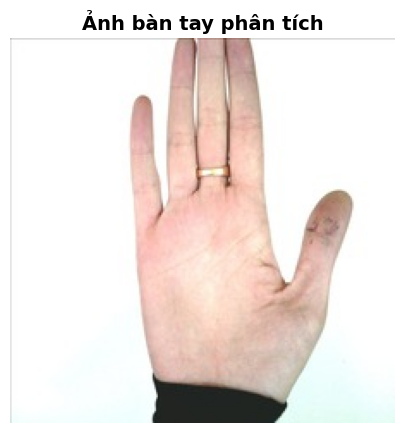

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

          KHẢO SÁT VẬN MỆNH QUA CHỈ TAY - KẾT QUẢ PHÂN TÍCH           

 [ĐƯỜNG TÂM ĐẠO] - Trạng thái nhận diện: DAI_VUOT
 Đường Tâm Đạo Dài Vượt Trội: Đời sống tình cảm vô cùng phong phú, giàu lòng vị tha, luôn hết mình vì người yêu thương nhưng đôi khi dễ bị cảm xúc chi phối.

 [ĐƯỜNG TRÍ ĐẠO] - Trạng thái nhận diện: DOC_THANG
 Đường Trí Đạo Dốc Thẳng: Tư duy logic, tỉnh táo và có óc tổ chức tuyệt vời. Bạn giải quyết vấn đề bằng cái đầu lạnh, rất phù hợp với ngành kỹ thuật, lập trình, khoa học.

 [ĐƯỜNG SINH ĐẠO] - Trạng thái nhận diện: TRUNG_BINH
Đường Sinh Đạo Trung Bình: Sức khỏe ổn định, cuộc sống bình yên, ít gặp sóng gió lớn. Bạn biết cách cân bằng giữa công việc và nghỉ ngơi.

   Lời khuyên: Kết quả mang tính chất tham khảo giải trí khoa học.    


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

# ==============================================================================
# 1. ĐỊNH NGHĨA TÍNH CHẤT VÀ DỰ ĐOÁN CHO 12 TRƯỜNG HỢP
# (Tên các Key phải trùng khớp 100% với tên thư mục trên Google Drive của bạn)
# ==============================================================================

fortune_database = {
    'sinh_dao': {
        'dai_cung': " Đường Sinh Đạo Dài, Sâu: Bạn có sức đề kháng tuyệt vời, cơ thể dẻo dai và tràn đầy năng lượng sống. Ít khi ốm vặt và có số mệnh trường thọ.",
        'mo_nhat': " Đường Sinh Đạo Mờ Nhạt: Sức khỏe ở mức trung bình, dễ bị mệt mỏi hoặc suy nhược khi làm việc quá sức. Bạn cần chú ý rèn luyện thể thao và ăn uống điều độ hơn.",
        'sau_ro': "Đường Sinh Đạo Sâu Rõ: Ý chí sinh tồn mạnh mẽ, khả năng phục hồi sau biến cố cực cao. Bạn luôn là chỗ dựa vững chắc cho người thân.",
        'trung_binh': "Đường Sinh Đạo Trung Bình: Sức khỏe ổn định, cuộc sống bình yên, ít gặp sóng gió lớn. Bạn biết cách cân bằng giữa công việc và nghỉ ngơi."
    },
    'tri_dao': {
        'doc_dai': "Đường Trí Đạo Dốc Dài: Bạn sở hữu trí tưởng tượng phong phú, trực giác nhạy bén và có năng khiếu nghệ thuật, sáng tạo cao. Rất hợp làm thiết kế, marketing hoặc nghệ thuật.",
        'doc_lom': "Đường Trí Đạo Dốc Lõm: Tư duy có phần khép kín nhưng đổi lại bạn có khả năng tập trung cực kỳ sâu sắc vào một lĩnh vực chuyên môn cụ thể.",
        'doc_ngan': "Đường Trí Đạo Dốc Ngắn: Bạn là người thực tế, phản xạ nhanh nhạy, đưa ra quyết định tốc hành. Bạn không thích sự dài dòng, rườm rà.",
        'doc_thang': " Đường Trí Đạo Dốc Thẳng: Tư duy logic, tỉnh táo và có óc tổ chức tuyệt vời. Bạn giải quyết vấn đề bằng cái đầu lạnh, rất phù hợp với ngành kỹ thuật, lập trình, khoa học."
    },
    'tam_dao': {
        'dai_vuot': " Đường Tâm Đạo Dài Vượt Trội: Đời sống tình cảm vô cùng phong phú, giàu lòng vị tha, luôn hết mình vì người yêu thương nhưng đôi khi dễ bị cảm xúc chi phối.",
        'hoi_doc': " Đường Tâm Đạo Hơi Dốc: Bạn kiểm soát cảm xúc khá tốt, yêu ghét rõ ràng, có xu hướng thực tế trong các mối quan hệ tình cảm.",
        'ngang_ngan': " Đường Tâm Đạo Ngang Ngắn: Bạn thuộc tuýp người lý trí, ít khi để con tim lấn át lý trí. Bạn giải quyết chuyện tình cảm rất dứt khoát và thẳng thắn.",
        'vong_giua': " Đường Tâm Đạo Vòng Giữa: Nhân duyên của bạn rất tốt, đi đâu cũng có bạn bè, quý nhân phù trợ. Đời sống hôn nhân sau này có xu hướng hòa hợp, hạnh phúc."
    }
}

# ==============================================================================
# 2. HÀM DỰ ĐOÁN VÀ XUẤT KẾT QUẢ TỔNG HỢP
# ==============================================================================

def predict_and_tell_fortune():
    print("👉 Hãy chọn một bức ảnh chụp lòng bàn tay rõ nét từ máy tính của bạn...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        path = fn

        # Đọc và tiền xử lý ảnh đầu vào
        img = image.load_img(path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Hiển thị ảnh lòng bàn tay lên Colab
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.title("Ảnh bàn tay phân tích", fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()

        # ----------------------------------------------------------------------
        # Thực hiện dự đoán từ 3 mô hình (Đã train ở Bước trước)
        # ----------------------------------------------------------------------
        # 1. Dự đoán Sinh Đạo
        pred_sinh_idx = np.argmax(model_sinh.predict(img_array))
        res_sinh_class = labels_sinh[pred_sinh_idx] # Trả về tên class (ví dụ: 'dai_cung')

        # 2. Dự đoán Trí Đạo
        pred_tri_idx = np.argmax(model_tri.predict(img_array))
        res_tri_class = labels_tri[pred_tri_idx] # Trả về tên class (ví dụ: 'doc_thang')

        # 3. Dự đoán Tâm Đạo
        pred_tam_idx = np.argmax(model_tam.predict(img_array))
        res_tam_class = labels_tam[pred_tam_idx] # Trả về tên class (ví dụ: 'vong_giua')

        # ----------------------------------------------------------------------
        # Giao diện xuất kết quả bói toán
        # ----------------------------------------------------------------------
        print("\n" + "="*70)
        print(" KHẢO SÁT VẬN MỆNH QUA CHỈ TAY - KẾT QUẢ PHÂN TÍCH  ".center(70))
        print("="*70)

        print(f"\n [ĐƯỜNG TÂM ĐẠO] - Trạng thái nhận diện: {res_tam_class.upper()}")
        print(fortune_database['tam_dao'].get(res_tam_class, "Không tìm thấy dữ liệu giải nghĩa."))

        print(f"\n [ĐƯỜNG TRÍ ĐẠO] - Trạng thái nhận diện: {res_tri_class.upper()}")
        print(fortune_database['tri_dao'].get(res_tri_class, "Không tìm thấy dữ liệu giải nghĩa."))

        print(f"\n [ĐƯỜNG SINH ĐẠO] - Trạng thái nhận diện: {res_sinh_class.upper()}")
        print(fortune_database['sinh_dao'].get(res_sinh_class, "Không tìm thấy dữ liệu giải nghĩa."))

        print("\n" + "="*70)
        print("Lời khuyên: Kết quả mang tính chất tham khảo giải trí khoa học.".center(70))
        print("="*70)

# ==============================================================================
# 3. KÍCH HOẠT CHẠY ỨNG DỤNG
# ==============================================================================
predict_and_tell_fortune()

In [22]:
import os
import numpy as np
import gradio as gr
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ==============================================================================
# 1. CƠ SỞ DỮ LIỆU GIẢI NGHĨA (FORTUNE DATABASE)
# ==============================================================================
fortune_database = {
    'sinh_dao': {
        'dai_cung': "✨ Sức đề kháng tuyệt vời, cơ thể dẻo dai và tràn đầy năng lượng sống. Ít khi ốm vặt và sở hữu số mệnh trường thọ, hậu vận an khang.",
        'mo_nhat': "✨ Sức khỏe ở mức trung bình, dễ bị mệt mỏi hoặc suy nhược khi làm việc quá sức. Bạn nên chú ý điều độ trong lối sống và rèn luyện thể thao.",
        'sau_ro': "✨ Ý chí sinh tồn mãnh liệt, khả năng phục hồi sau biến cố cực kỳ cao. Bạn luôn là chỗ dựa tinh thần vững chắc cho những người xung quanh.",
        'trung_binh': "✨ Sức khỏe ổn định, cuộc sống bình yên và ít gặp sóng gió lớn. Bạn có khả năng cân bằng rất tốt giữa sự nghiệp và nghỉ ngơi."
    },
    'tri_dao': {
        'doc_dai': "✨ Trí tưởng tượng bay bổng, trực giác nhạy bén và có thiên hướng nghệ thuật, sáng tạo cao. Rất phù hợp với các lĩnh vực thiết kế, nghệ thuật hoặc chiến lược.",
        'doc_lom': "✨ Tư duy có chiều sâu, thiên về nội tâm. Khả năng nghiên cứu độc lập và tập trung cực kỳ xuất sắc vào một lĩnh vực chuyên môn cụ thể.",
        'doc_ngan': "✨ Con người thực tế, hành động nhạy bén và đưa ra quyết định tốc hành. Bản tính thẳng thắn, quyết đoán, không thích sự rườm rà, dài dòng.",
        'doc_thang': "✨ Tư duy logic, tỉnh táo và có óc tổ chức tuyệt vời. Luôn giải quyết vấn đề bằng cái đầu lạnh, rất phù hợp với khoa học, lập trình, quản lý."
    },
    'tam_dao': {
        'dai_vuot': "✨ Đời sống tình cảm vô cùng phong phú, giàu lòng vị tha, luôn hết mình vì người yêu thương nhưng đôi khi dễ để cảm xúc lấn át lý trí.",
        'hoi_doc': "✨ Kiểm soát cảm xúc rất tốt, yêu ghét phân minh, có xu hướng thực tế và chín chắn trong các mối quan hệ tình cảm.",
        'ngang_ngan': "✨ Thuộc tuýp người lý trí cao. Bạn giải quyết chuyện tình cảm rất dứt khoát, thẳng thắn và không thích sự mập mờ.",
        'vong_giua': "✨ Nhân duyên vượng phát, đi đâu cũng có tri kỷ và quý nhân phù trợ. Đời sống gia đình sau này có xu hướng rất hòa hợp, viên mãn."
    }
}

# ==============================================================================
# 2. HÀM XỬ LÝ NHẬN DIỆN VÀ TRẢ VỀ GIAO DIỆN
# ==============================================================================
def predict_palmistry(input_img):
    if input_img is None:
        return "<div style='color: #ff4d4d; text-align: center; font-weight: bold;'>Vui lòng cung cấp hoặc chụp ảnh lòng bàn tay rõ nét!</div>"

    try:
        # Tiền xử lý ảnh từ giao diện đưa vào mô hình (Gradio tự chuyển ảnh thành mảng numpy)
        import cv2
        img_resized = cv2.resize(input_img, (224, 224))
        img_array = img_resized / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Thực hiện dự đoán từ 3 mô hình (Đảm bảo model_sinh, model_tri, model_tam đã train thành công trước đó)
        res_sinh_class = labels_sinh[np.argmax(model_sinh.predict(img_array))]
        res_tri_class = labels_tri[np.argmax(model_tri.predict(img_array))]
        res_tam_class = labels_tam[np.argmax(model_tam.predict(img_array))]

        # Lấy nội dung luận giải
        txt_tam = fortune_database['tam_dao'].get(res_tam_class, "Chưa có dữ liệu.")
        txt_tri = fortune_database['tri_dao'].get(res_tri_class, "Chưa có dữ liệu.")
        txt_sinh = fortune_database['sinh_dao'].get(res_sinh_class, "Chưa có dữ liệu.")

        # Xây dựng giao diện kết quả bằng HTML/CSS sang trọng với tone màu Vàng Ghi / Đen Vàng (Luxury Gold)
        html_output = f"""
        <div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; padding: 15px; border-radius: 12px; background: #1a1a2e; color: #fff; border: 1px solid #d4af37;">
            <h2 style="color: #d4af37; text-align: center; margin-bottom: 20px; letter-spacing: 2px; font-weight: bold;">🔮 KẾT QUẢ PHÂN TÍCH THỜI VẬN 🔮</h2>
            <hr style="border-color: #d4af37; margin-bottom: 20px;">

            <div style="margin-bottom: 20px;">
                <h4 style="color: #ff4757; margin-bottom: 5px; font-weight: bold;">❤️ ĐƯỜNG TÂM ĐẠO (Tình Duyên & Cảm Xúc)</h4>
                <p style="font-style: italic; color: #ced4da; margin-bottom: 5px;">Trạng thái nhận diện: <b style="color: #fff;">{res_tam_class.replace('_', ' ').upper()}</b></p>
                <p style="line-height: 1.6; font-size: 15px;">{txt_tam}</p>
            </div>

            <div style="margin-bottom: 20px;">
                <h4 style="color: #1e90ff; margin-bottom: 5px; font-weight: bold;">🧠 ĐƯỜNG TRÍ ĐẠO (Tư Duy & Sự Nghiệp)</h4>
                <p style="font-style: italic; color: #ced4da; margin-bottom: 5px;">Trạng thái nhận diện: <b style="color: #fff;">{res_tri_class.replace('_', ' ').upper()}</b></p>
                <p style="line-height: 1.6; font-size: 15px;">{txt_tri}</p>
            </div>

            <div style="margin-bottom: 10px;">
                <h4 style="color: #2ed573; margin-bottom: 5px; font-weight: bold;">🌱 ĐƯỜNG SINH ĐẠO (Sức Khỏe & Bản Mệnh)</h4>
                <p style="font-style: italic; color: #ced4da; margin-bottom: 5px;">Trạng thái nhận diện: <b style="color: #fff;">{res_sinh_class.replace('_', ' ').upper()}</b></p>
                <p style="line-height: 1.6; font-size: 15px;">{txt_sinh}</p>
            </div>

            <hr style="border-color: #d4af37; margin-top: 25px;">
            <p style="text-align: center; font-size: 12px; color: #a4b0be; margin-bottom: 0;">* Chiêm tinh học mang tính chất tham khảo, hãy luôn làm chủ vận mệnh của chính mình *</p>
        </div>
        """
        return html_output
    except Exception as e:
        return f"<div style='color: #ff4d4d;'>Đã xảy ra lỗi hệ thống: {str(e)}</div>"

# ==============================================================================
# 3. THIẾT KẾ GIAO DIỆN LUXURY WEB UI (GRADIO BLOCKS)
# ==============================================================================
custom_css = """
body, .gradio-container { background-color: #0d0d1a !important; color: #ffffff !important; }
.feedback-header { text-align: center; padding: 20px; }
button.primary { background: linear-gradient(45deg, #9b5de5, #d4af37) !important; color: white !important; font-weight: bold !important; border: none !important; }
button.primary:hover { transform: scale(1.02); transition: all 0.2s ease-in-out; }
"""

with gr.Blocks(css=custom_css, title="Tay Ải Tay AI") as demo:

    # Tiêu đề ứng dụng
    with gr.Row():
        gr.HTML("""
        <div style="text-align: center; margin-top: 20px; margin-bottom: 10px;">
            <h1 style="color: #d4af37; font-family: 'Georgia', serif; font-size: 32px; letter-spacing: 3px; font-weight: bold;">Tay Ải Tay AI</h1>
            <p style="color: #a4b0be; font-size: 16px; font-style: italic;">Sự kết hợp giữa nhân tướng học phương Đông và Trí tuệ nhân tạo Deep Learning</p>
        </div>
        """)

    # Bố cục giao diện chính (Chia đôi màn hình Trái/Phải)
    with gr.Row():
        # Cột bên trái: Cho phép người dùng chụp ảnh từ webcam hoặc tải file lên
        with gr.Column(scale=1):
            gr.Markdown("### 📸 Cung cấp ảnh lòng bàn tay")
            input_image = gr.Image(
                label="Chụp trực tiếp từ Webcam hoặc tải file lên",
                sources=["webcam", "upload"],
                type="numpy"
            )
            submit_btn = gr.Button("🔮 KHỞI LẬP HUYỀN CƠ", variant="primary")

        # Cột bên phải: Xuất kết quả bói toán bằng giao diện HTML
        with gr.Column(scale=1):
            gr.Markdown("### 📜 Kết quả luận giải ")
            output_html = gr.HTML(
                value="<div style='text-align: center; color: #747d8c; padding: 50px;'>Hệ thống đang chờ lệnh... Hãy chụp hoặc tải ảnh bàn tay lên sau đó nhấn nút phía đối diện.</div>"
            )

    # Sự kiện click nút bấm kích hoạt AI giải mã
    submit_btn.click(fn=predict_palmistry, inputs=input_image, outputs=output_html)

# ==============================================================================
# 4. CHẠY ỨNG DỤNG VÀ PHÁT HÀNH ĐƯỜNG LINK LINK PUBLIC
# ==============================================================================
# Thuộc tính share=True sẽ tạo một đường link .gradio.live để bạn gửi cho bạn bè hoặc thầy cô xem thử qua điện thoại/máy tính khác.
demo.launch(share=True, debug=True)

/tmp/ipykernel_1142/1415786705.py:97: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="Tay Ải Tay AI") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3dd9baccf9d1a59070.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3dd9baccf9d1a59070.gradio.live
